# (연구) HST example 3

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [논문연구]

### 실험환경 

In [42]:
!conda env list

# conda environments:
#
base                     /home/cgb3/anaconda3
py39r40               *  /home/cgb3/anaconda3/envs/py39r40



### import

In [105]:
from IPython.display import HTML
def show(fig): 
    return HTML(fig.to_html(include_plotlyjs='cdn',include_mathjax=False, config=dict({'scrollZoom':False})))

In [106]:
## 1. remove trash
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('image', cmap='Greys')
import rpy2 
%load_ext rpy2.ipython
%run pybase
%run heavysnow 
plt.style.use('ggplot')

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


### load data

In [107]:
n=23
f=np.array(pd.read_csv("2021-08-15-MCU-ticket.csv").Worldwide)/1000000
V=np.array(pd.read_csv("2021-08-15-MCU-ticket.csv").Film)
W=np.array(pd.read_csv("2021-08-15-MCU-weights.csv",index_col=0))-np.eye(n,n)

### HST

In [122]:
gs=GraphSignal(V,W,f)
hst=HeavysnowTransform(gs)
hst.snow(tau=100000,b=1,maxflow=n)

HST (tau= 100000, b=1)
100000/100000
HST completed and all history is recorded.


/home/cgb3/Dropbox/01_yechan/_notebooks/heavysnow.py:11: RuntimeWarning:

invalid value encountered in true_divide



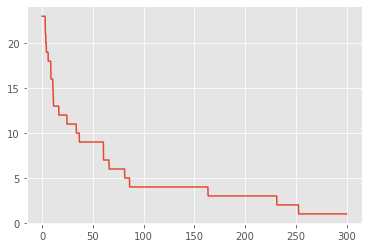

In [123]:
def choose_theta(maxtheta=300):
    y=[]
    x=np.arange(start=0.01,stop=maxtheta,step=0.1)
    for i in range(len(x)):
        hst.adjustingtheta(x[i]) 
        gs=GraphSignal(V,hst.snowweight,f)
        spa=SpectralAnalysis(gs)
        spa.graphFouriertransform()
        spa.decompose()        
        y.append(sum(abs(spa.lamb)<0.001))
    plt.plot(x,y)    
choose_theta()   

In [124]:
hst.adjustingtheta(300)

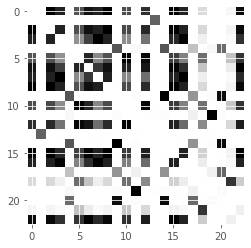

In [125]:
plt.imshow(hst.snowweight)

In [126]:
_type=['solo']*5+['multi']+['solo']*4+['multi']+['solo']+['multi']+['solo']*5+['multi']+['solo']*2+['multi']+['solo']
df=pd.DataFrame({'V':hst.V,'f':hst.f,'divlink':hst.graphweight.sum(axis=1), 'conlink':hst.graphweight.sum(axis=0),'type':_type})
df

,V,f,divlink,conlink,type
0,Iron Man,585.174222,4.000000,2.515815,solo
1,The Incredible Hulk,263.427551,1.000000,0.294608,solo
2,Iron Man 2,623.933331,4.153846,3.107363,solo
3,Thor,449.326618,2.562500,2.241890,solo
4,Captain America: The First Avenger,370.569774,1.750000,0.948269,solo
5,The Avengers,1518.812988,4.647059,4.332114,multi
6,Iron Man 3,1214.811252,3.200000,1.690351,solo
7,Thor: The Dark World,644.571402,2.411765,2.147921,solo
8,Captain America: The Winter Soldier,714.264267,3.266667,2.455757,solo
9,Guardians of the Galaxy,773.328629,1.631579,1.212075,solo


In [127]:
import plotly.graph_objects as go

_colorscale=[
        [0, 'rgb(0, 0, 0)'],
        [1./10000, 'rgb(50, 50, 50)'],
        [1./1000, 'rgb(100, 100, 100)'],
        [1./100, 'rgb(150, 150, 150)'],
        [1./10, 'rgb(200, 200, 200)'],
        [1., 'rgb(255, 255, 255)'],
        ]
_colorbar= dict(
        tick0= 0,
        tickmode= 'array',
        tickvals= [-5, 0, 5, 10])

_mode ='wrap'
_filter = np.array([1,1])*0.5

_z1 = np.diag(hst.snowygrounds[:,0])+0
_z2 = np.diag(hst.snowygrounds[:,25000])+5000
_z3 = np.diag(hst.snowygrounds[:,50000])+10000
_z4 = np.diag(hst.snowygrounds[:,75000])+15000
_z5 = np.diag(hst.snowygrounds[:,100000])+20000

# _z1=scipy.ndimage.filters.gaussian_filter(_z1, _filter, mode=_mode) 
# _z2=scipy.ndimage.filters.gaussian_filter(_z2, _filter, mode=_mode)
# _z3=scipy.ndimage.filters.gaussian_filter(_z3, _filter, mode=_mode)
# _z4=scipy.ndimage.filters.gaussian_filter(_z4, _filter, mode=_mode)


fig = go.Figure([go.Surface(x = df.conlink, y = df.divlink, z = _z1, colorscale=_colorscale, colorbar=_colorbar, showscale=False),
                 go.Surface(x = df.conlink, y = df.divlink, z = _z2, colorscale=_colorscale, colorbar=_colorbar, showscale=False),
                 go.Surface(x = df.conlink, y = df.divlink, z = _z3, colorscale=_colorscale, colorbar=_colorbar, showscale=False),
                 go.Surface(x = df.conlink, y = df.divlink, z = _z4, colorscale=_colorscale, colorbar=_colorbar, showscale=False),
                 go.Surface(x = df.conlink, y = df.divlink, z = _z5, colorscale=_colorscale, colorbar=_colorbar, showscale=False)])
fig.update_layout(width=1000,height=1000, scene_camera_eye=dict(x=-2.5, y=-2.5, z=0.05))
show(fig)
fig.write_image('2022-01-13-snow.pdf')  

### R 환경으로.. 

In [128]:
import rpy2 
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [129]:
n=hst.n 
V=hst.V
f=hst.f 
WEuclid= hst.euclidweight
Wgraph= (hst.graphweight+hst.graphweight.T)/2
Whst= hst.snowweight
W= hst.graphweight

In [130]:
%R -i n
%R -i V
%R -i f
%R -i WEuclid
%R -i Wgraph
%R -i Whst
%R -i W

### 그림1시각화 

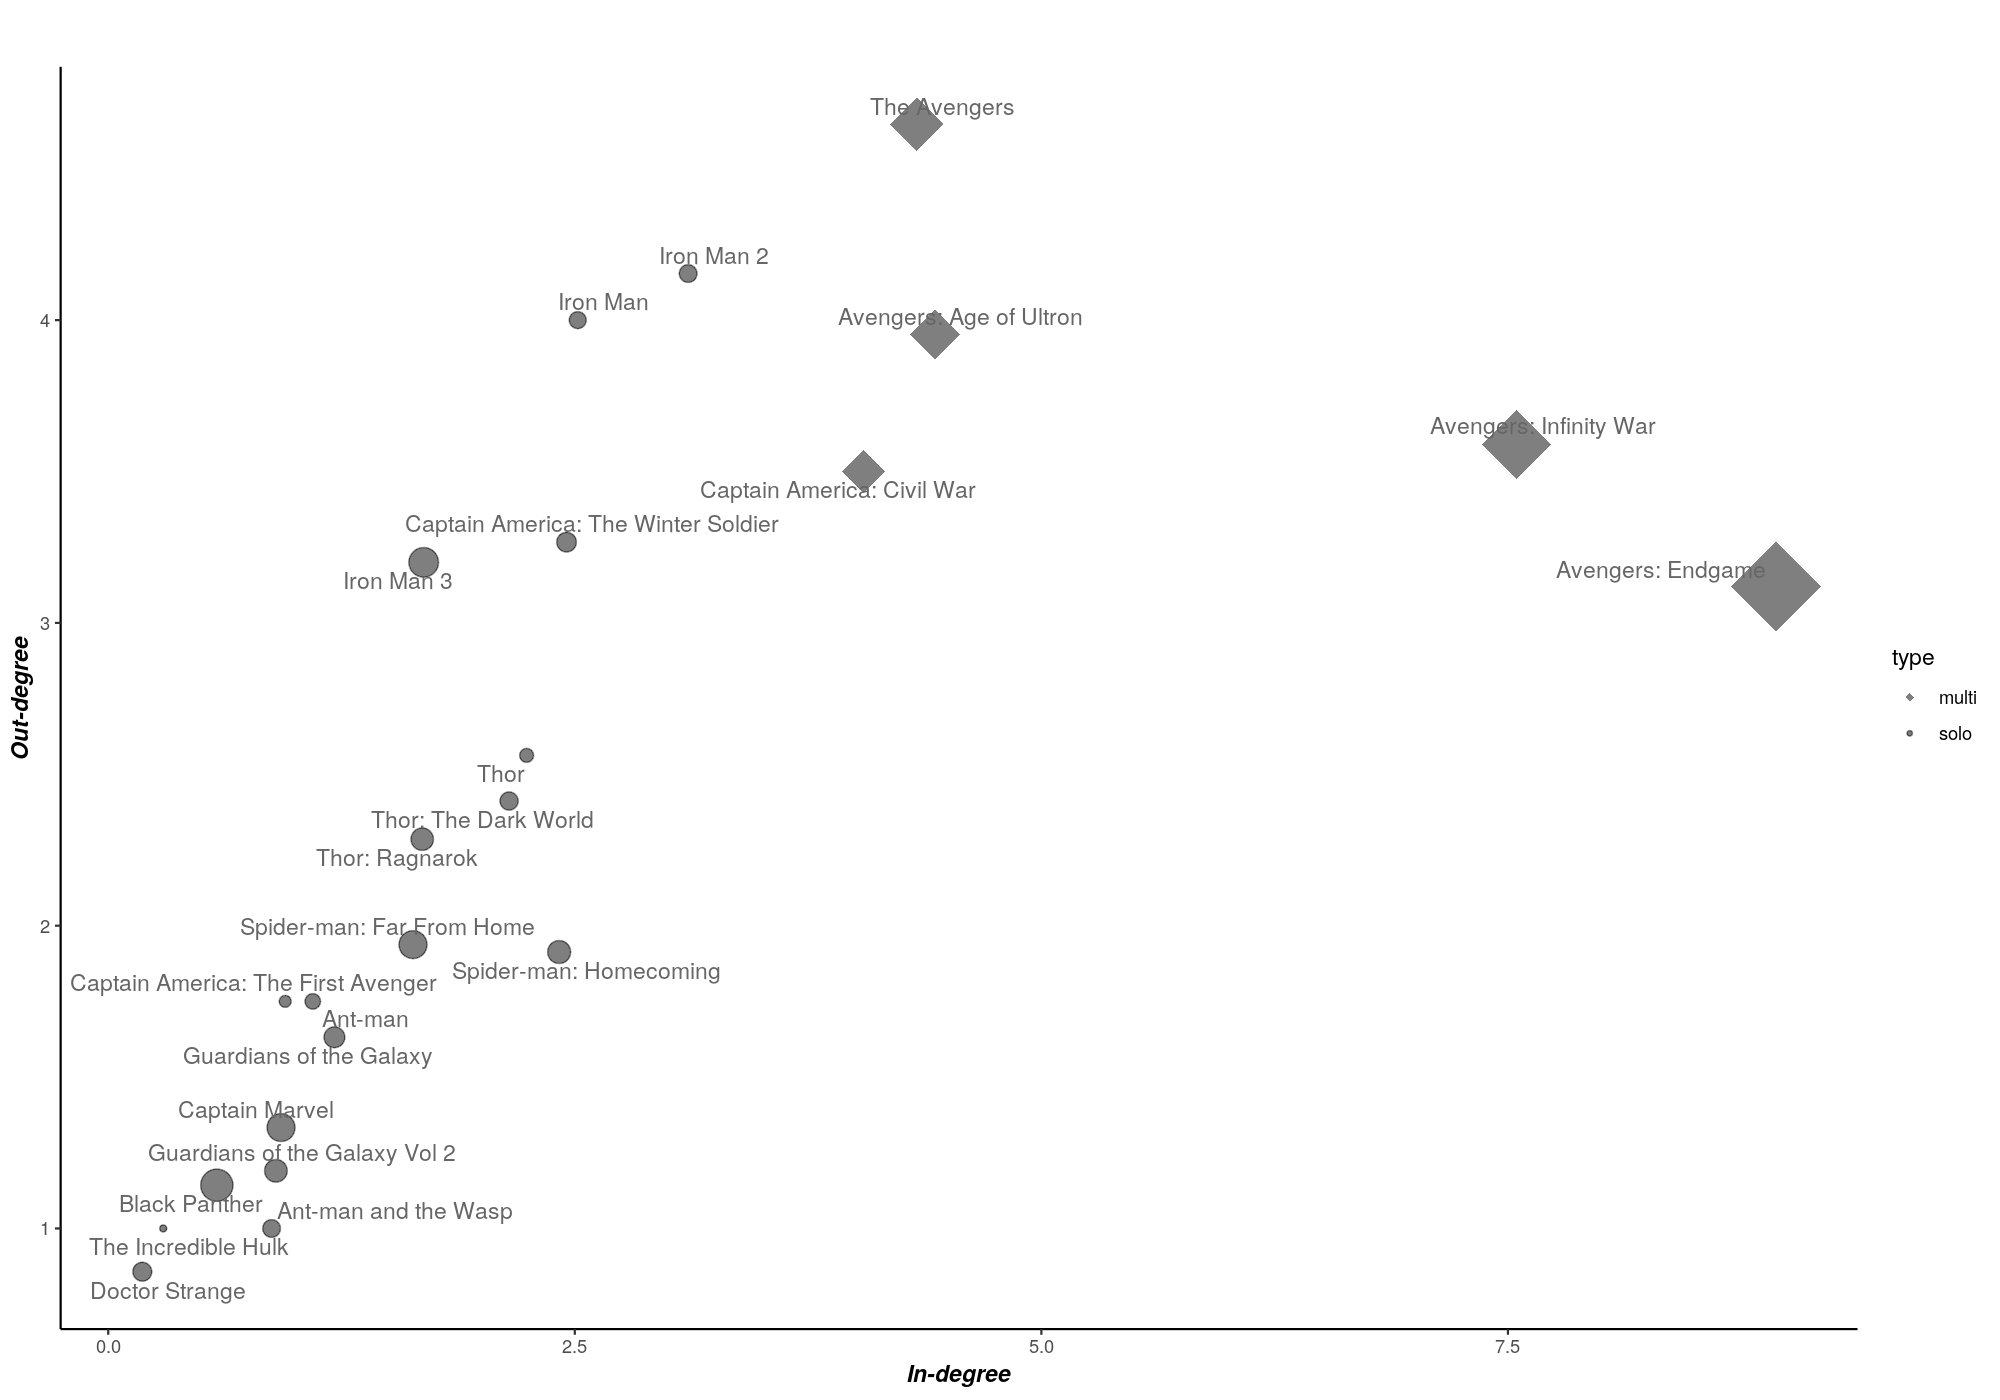

In [131]:
%%R -w 2000 -h 1400 -r 150
library(tidyverse)
list(n=n,V=V,f=f,WEuclid=WEuclid,Wgraph=Wgraph,Whst=Whst,W=W) %>% saveRDS(file = "2022-01-13.rds")
source('heavysnow.R')
df<-tibble(V)
df$f<-as.vector(f) 
df$divlink<-0
df$conlink<-0
df$link<-0
for(i in 1:23){
    df$divlink[i]<-sum(W[i,])
    df$conlink[i]<-sum(W[,i])
    df$link[i]<-(sum(W[i,])+sum(W[,i]))/2
}
df$type<-rep('solo',23)
df[V %in% c("The Avengers" ,"Avengers: Age of Ultron","Captain America: Civil War","Avengers: Infinity War","Avengers: Endgame"),'type']='multi'
p1<-ggplot(df, aes(x=conlink, y=divlink,z=f))+
    geom_point(aes(x=conlink, y=divlink,size=f**2,shape=type),alpha=0.5)+
    scale_size(range=c(2,20))+
    #scale_alpha_manual(values=c(1,0.6))+
    scale_shape_manual(values=c(18,20))+
    theme_classic()+
    guides(size=F)+
    geom_text_repel(aes(x=conlink,y=divlink,label=V),col="gray40")+
    #geom_density2d(aes(x=conlink,y=divlink,fill=tatf,color=f)),+
    ylab("Out-degree")+xlab("In-degree")+
    ggtitle("")+theme(plot.title=element_text(face="bold.italic",size=rel(2)))+
    theme(axis.title.x=element_text(face=4,size=rel(1)))+theme(axis.title.y=element_text(face=4,size=rel(1)))
    #theme(legend.position = "none")
show(p1)
ggsave(plot=p1,"./2022-01-13-p1.pdf",width=10,height=7)

### 그래프퓨리에변환 -> 시각화  

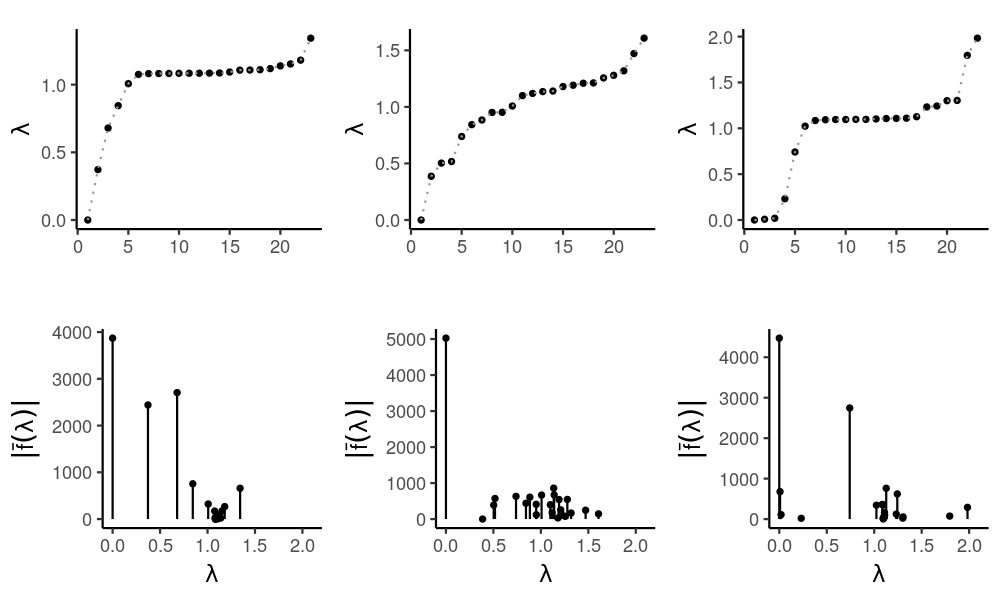

In [132]:
%%R -w 1000 -h 600 -r 150

g1<-gfft(f,WEuclid)
g2<-gfft(f,Wgraph)
g3<-gfft(f,Whst)

library(gridExtra)
e1<-eigenplot(g1)+theme(plot.title=element_text(face="bold.italic",size=rel(1)))
e2<-eigenplot(g2)+theme(plot.title=element_text(face="bold.italic",size=rel(1)))
e3<-eigenplot(g3)+theme(plot.title=element_text(face="bold.italic",size=rel(1)))
s1<-specplot(g1)
s2<-specplot(g2)
s3<-specplot(g3)
p2<-grid.arrange(e1,e2,e3,s1,s2,s3,nrow=2)
ggsave(plot=p2,"./2022-01-13-p2.pdf",width=5,height=3)

### 분해 

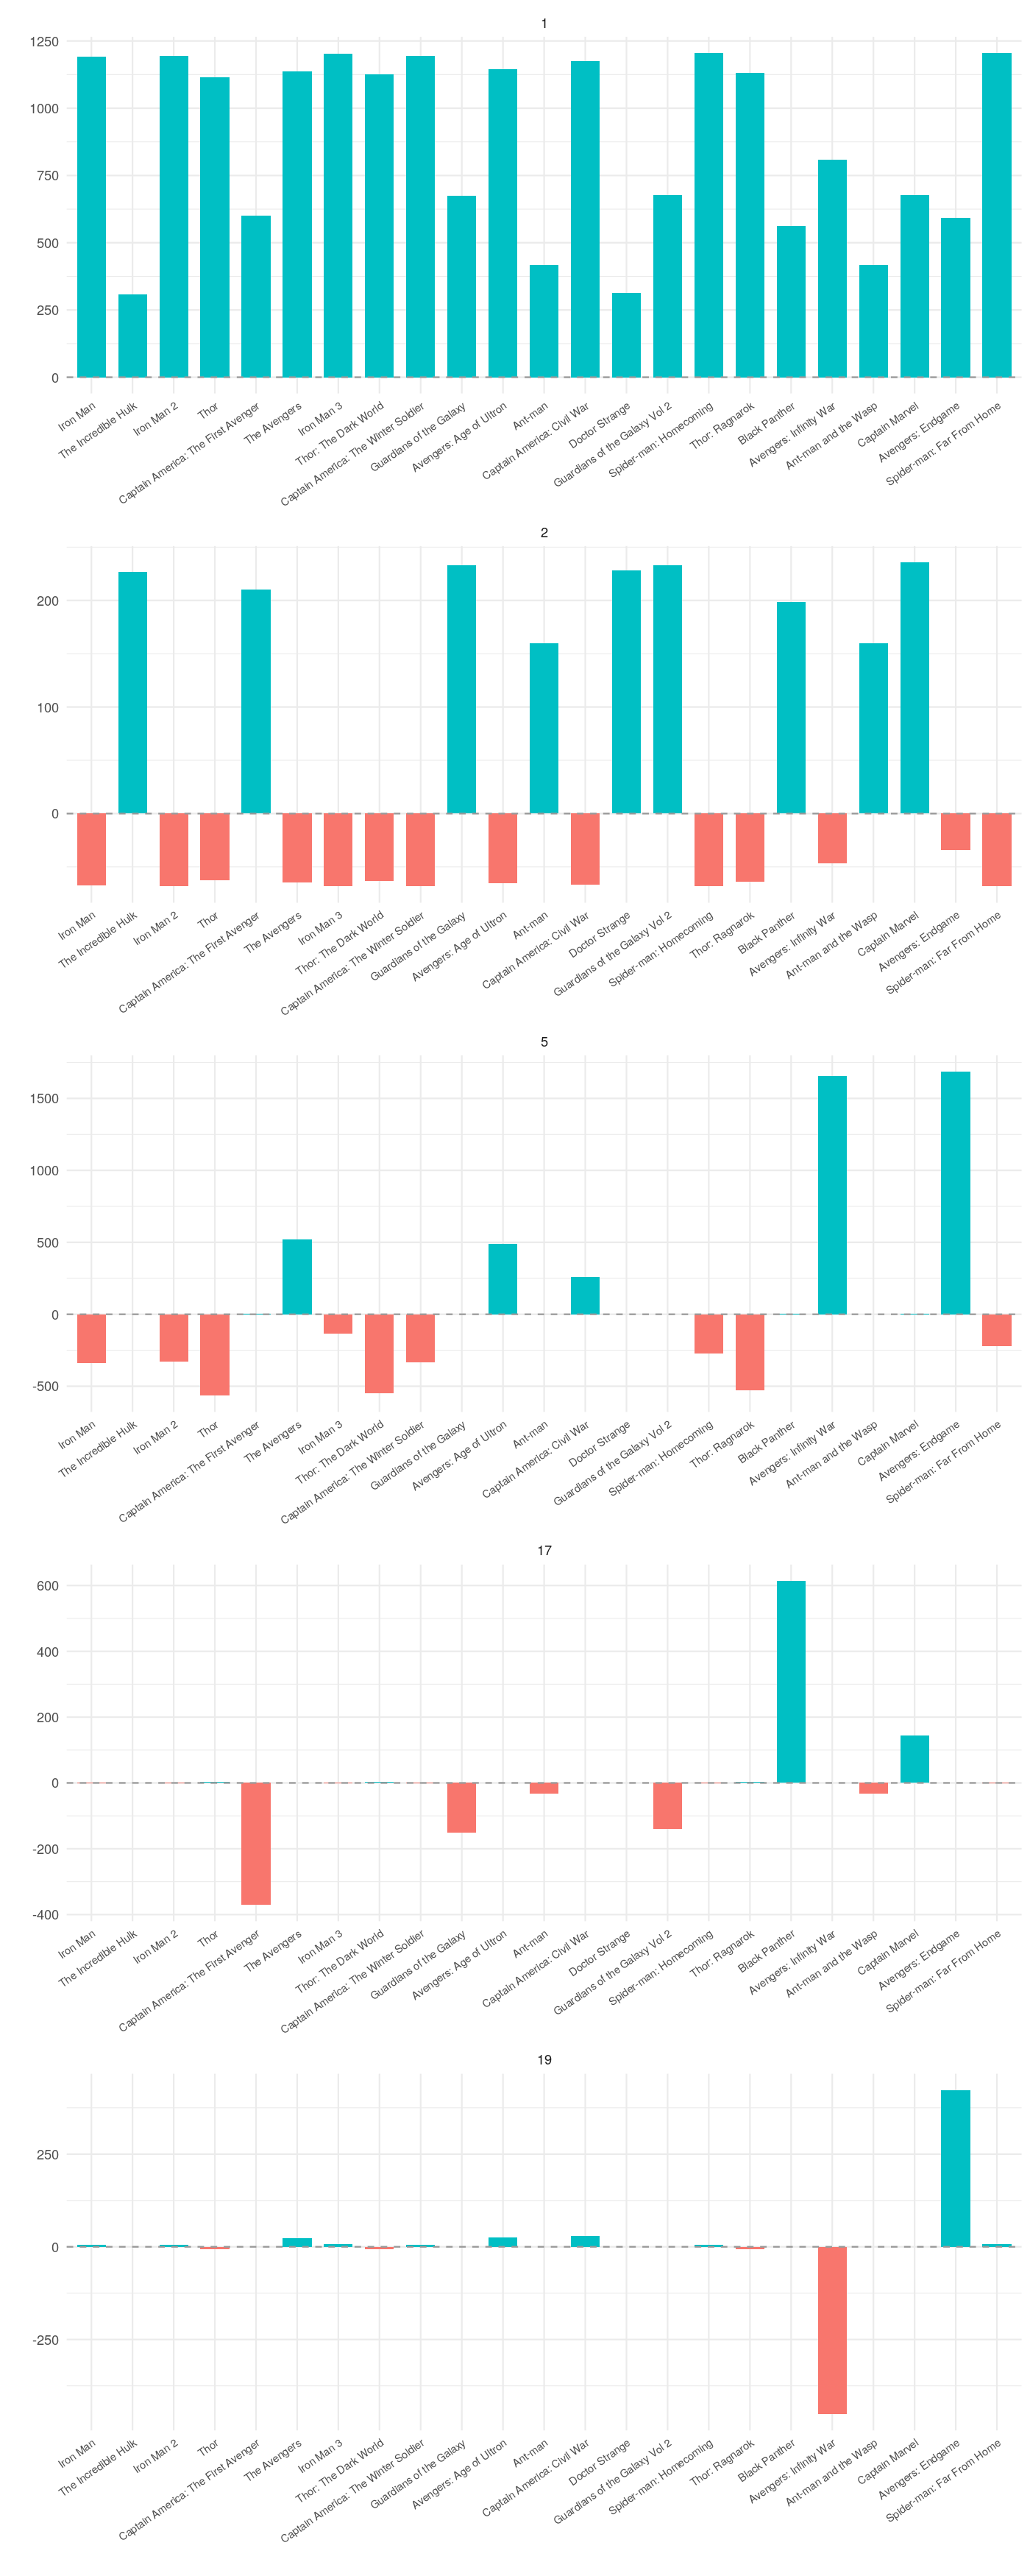

In [134]:
%%R -w 1400 -h 3500 -r 150 
d1<-decompose(f,WEuclid,V=V) # 0, 35000, 60000, 80000
d2<-decompose(f,Wgraph,V=V) # 0, 35000, 60000, 80000
d3<-decompose(f,Whst,V=V) # 0, 35000, 60000, 80000

d1$case<-"Euclid"
d2$case<-"Graph"
d3$case<-"HST"
df2_ <-rbind(d1,d2,d3)
df2_ %>% group_by(case,eigenvectorindex) #%>% mutate(textsize= 10*(abs(fhat)>70))
df2=merge(df, df2_ %>% group_by(case,eigenvectorindex) %>% mutate(textsize= 10*(abs(fhat)>70))) %>% as_tibble

complst_ = c() 
for(i in 1:23) complst_[i] = sum(filter(df2,eigenvectorindex==i,case=='HST')$fhat**2)/sum(filter(df2,eigenvectorindex==i,case=='HST')$f**2)
selected_eigenvetorindex=which(complst_ > 0.01)

p3<-ggplot(data=filter(df2,eigenvectorindex %in% selected_eigenvetorindex, case=='HST'),aes(x=V,y=fhat))+
    geom_col(aes(fill=fhat>0),width=0.7)+
    #geom_text_repel(aes(x=Vindex,y=fhat,label=V,size=textsize),col=1,fontface=4,alpha=0.8,segment.size=0.2,segment.color="gray60",min.segment.length=5,hjust=0.1)+
    scale_radius(range = c(0,1.8))+
    guides(size=FALSE)+
    facet_wrap("eigenvectorindex",ncol=1,scales='free')+
    geom_hline(aes(yintercept=0),col="gray60",lty=2)+
    xlab("")+ylab("")+guides(fill=FALSE)+
    theme_minimal()+
    #theme(strip.text.x = element_text(angle=45,size = 10, color = "black", face = "bold.italic"))+
    #theme(strip.text.y = element_text(size = 10, color = "black", face = "bold.italic"))+
    theme(axis.text.x=element_text(angle=35, hjust=1, vjust=1,size=rel(0.8)))+
    theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))+
    scale_x_discrete(limits=V)
show(p3)
ggsave(plot=p3,"./2022-01-13-p3.pdf",width=7,height=7*2.5)

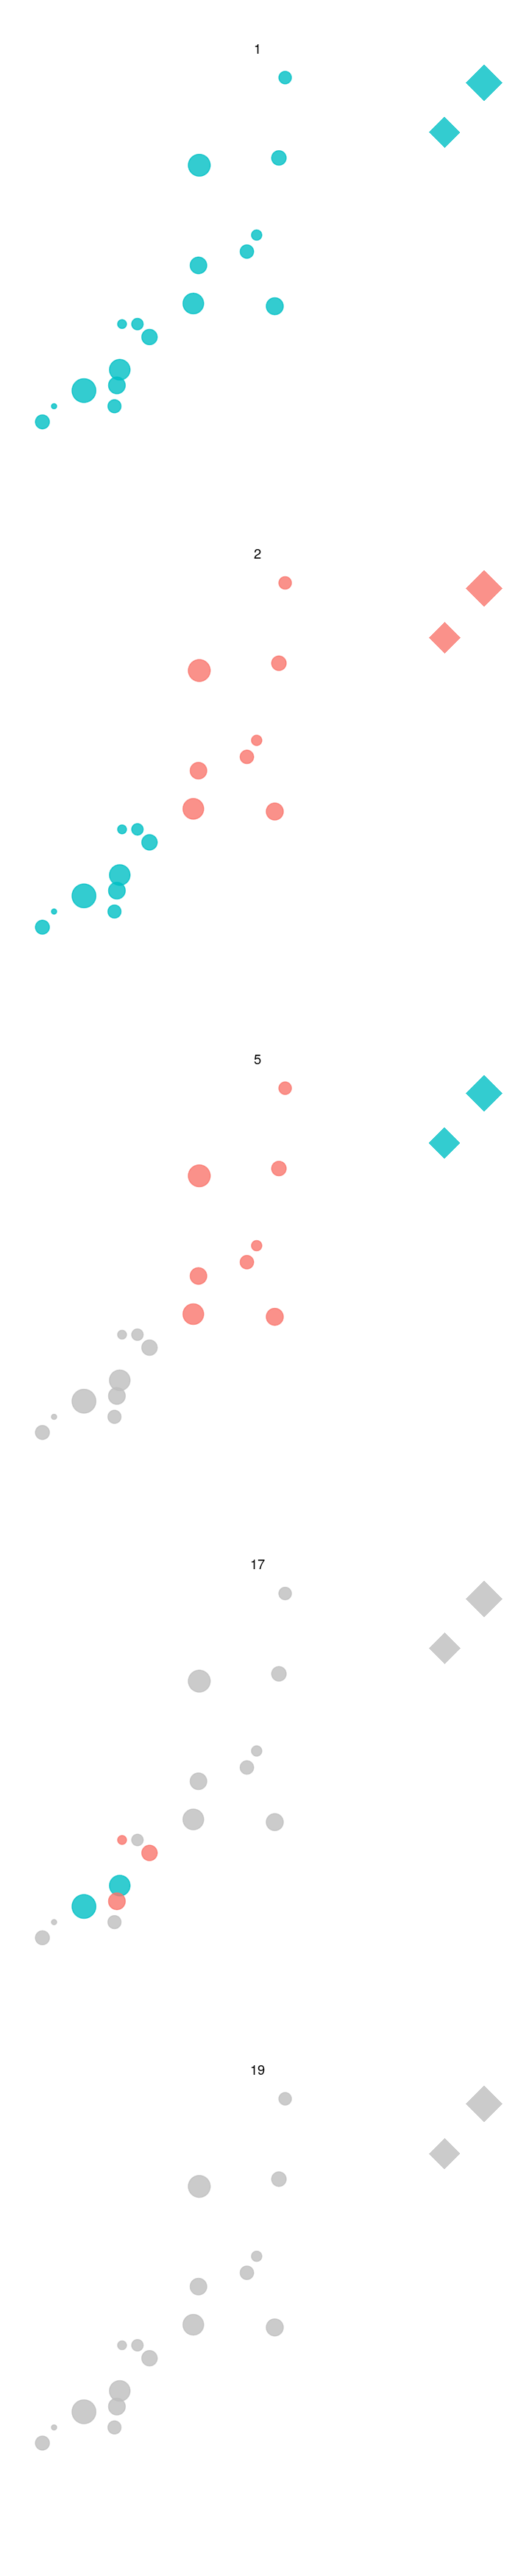

In [137]:
%%R -r 150 -w 700 -h 3500
p4<-ggplot(data=filter(df2,eigenvectorindex %in% selected_eigenvetorindex, case=='HST'),aes(x=V,y=fhat))+
    geom_point(aes(x=conlink, y=divlink,size=f**2,col=ifelse(abs(fhat)<50,'Gray',ifelse(fhat>0,'Blue','Red')),shape=type),alpha=0.8)+
    scale_colour_manual(values = c("#00BFC4", "gray", "#F8766D"))+
    scale_size(range=c(2,20))+
    facet_wrap("eigenvectorindex",ncol=1,scales='free')+    
    scale_shape_manual(values=c(18,20))+
    theme_void()+
    xlab("")+ylab("")+ylim(c(0,4))+xlim(c(0,4.5))+
    guides(size=F,shape=F)+
    ggtitle("")+theme(plot.title=element_text(face="bold.italic",size=rel(2)))+
    theme(axis.title.x=element_text(face=4,size=rel(1)))+theme(axis.title.y=element_text(face=4,size=rel(1)))+
    theme(legend.position = "none")
show(p4)
ggsave(plot=p4,"./2022-01-13-p4.pdf",width=3.5,height=7*2.5)

In [89]:
%%R
## 1. define friendship 
library(igraph)
frnd_ship<-friendship(W)
    
## 2. define relations
relations<-expand.grid(from=V, to=V)
relations<-cbind(relations,frnd_ship)
    
    
## 3. make gdf and weight
library(ggraph)
gdf<-graph_from_data_frame(relations[frnd_ship>0,],directed=TRUE,vertices=V)
wght<-frnd_ship[frnd_ship>0]

df_ = filter(df2,eigenvectorindex %in% selected_eigenvetorindex, case=='HST') %>% mutate(col=ifelse(abs(fhat)<30,'Gray',ifelse(fhat>0,'Blue','Red'))) %>% select(Vindex,eigenvectorindex,col)
col=(df_%>% filter(eigenvectorindex==selected_eigenvetorindex[1]) %>% arrange(Vindex))$col
p_temp1 <- ggraph(gdf)+theme_void()+
        geom_edge_arc(curvature=0.1,aes(alpha=frnd_ship),edge_width=0.2,arrow=arrow(length=unit(2,'mm'),type='closed',angle=10),linewidth=20)+
        geom_node_point(size=3+f/100,alpha=0.7,aes(color=col))+
        scale_colour_manual(values = c("#00BFC4"))+
        #geom_node_text(aes(label = V,size=f), color="black", repel=T,fontface=4)+
        guides(size='none') + guides(edge_alpha='none') + guides(color='none')+
        ggtitle("")+ theme(plot.title=element_text(hjust=0.09))+theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))
ggsave(plot=p_temp1,'2022-01-13-p_temp1.pdf',width=3.5,height=7*2.5/5)

col=(df_%>% filter(eigenvectorindex==selected_eigenvetorindex[2]) %>% arrange(Vindex))$col
p_temp2<- ggraph(gdf)+theme_void()+
        geom_edge_arc(curvature=0.1,aes(alpha=frnd_ship),edge_width=0.2,arrow=arrow(length=unit(2,'mm'),type='closed',angle=10),linewidth=20)+
        geom_node_point(size=3+f/100,alpha=0.7,aes(color=col))+
        scale_colour_manual(values = c("#F8766D","#00BFC4"))+
        #geom_node_text(aes(label = V,size=f), color="black", repel=T,fontface=4)+
        guides(size='none') + guides(edge_alpha='none') + guides(color='none')+
        ggtitle("")+ theme(plot.title=element_text(hjust=0.09))+theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))
ggsave(plot=p_temp2,'2022-01-13-p_temp2.pdf',width=3.5,height=7*2.5/5)

col=(df_%>% filter(eigenvectorindex==selected_eigenvetorindex[3]) %>% arrange(Vindex))$col
p_temp3<- ggraph(gdf)+theme_void()+
        geom_edge_arc(curvature=0.1,aes(alpha=frnd_ship),edge_width=0.2,arrow=arrow(length=unit(2,'mm'),type='closed',angle=10),linewidth=20)+
        geom_node_point(size=3+f/100,alpha=0.7,aes(color=col))+
        scale_colour_manual(values = c("#00BFC4", "gray", "#F8766D"))+
        #geom_node_text(aes(label = V,size=f), color="black", repel=T,fontface=4)+
        guides(size='none') + guides(edge_alpha='none') + guides(color='none')+
        ggtitle("")+ theme(plot.title=element_text(hjust=0.09))+theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))
ggsave(plot=p_temp3,'2022-01-13-p_temp3.pdf',width=3.5,height=7*2.5/5)

col=(df_%>% filter(eigenvectorindex==selected_eigenvetorindex[4]) %>% arrange(Vindex))$col
p_temp4<- ggraph(gdf)+theme_void()+
        geom_edge_arc(curvature=0.1,aes(alpha=frnd_ship),edge_width=0.2,arrow=arrow(length=unit(2,'mm'),type='closed',angle=10),linewidth=20)+
        geom_node_point(size=3+f/100,alpha=0.7,aes(color=col))+
        scale_colour_manual(values = c("#00BFC4", "gray", "#F8766D"))+
        #geom_node_text(aes(label = V,size=f), color="black", repel=T,fontface=4)+
        guides(size='none') + guides(edge_alpha='none') + guides(color='none')+
        ggtitle("")+ theme(plot.title=element_text(hjust=0.09))+theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))
ggsave(plot=p_temp4,'2022-01-13-p_temp4.pdf',width=3.5,height=7*2.5/5)

col=(df_%>% filter(eigenvectorindex==selected_eigenvetorindex[5]) %>% arrange(Vindex))$col
p_temp5<- ggraph(gdf)+theme_void()+
        geom_edge_arc(curvature=0.1,aes(alpha=frnd_ship),edge_width=0.2,arrow=arrow(length=unit(2,'mm'),type='closed',angle=10),linewidth=20)+
        geom_node_point(size=3+f/100,alpha=0.7,aes(color=col))+
        scale_colour_manual(values = c("#00BFC4", "gray", "#F8766D"))+
        #geom_node_text(aes(label = V,size=f), color="black", repel=T,fontface=4)+
        guides(size='none') + guides(edge_alpha='none') + guides(color='none')+
        ggtitle("")+ theme(plot.title=element_text(hjust=0.09))+theme(plot.title=element_text(face="bold.italic",size=rel(1.5)))
ggsave(plot=p_temp5,'2022-01-13-p_temp5.pdf',width=3.5,height=7*2.5/5)

R[write to console]: Using `stress` as default layout

R[write to console]: Using `stress` as default layout

R[write to console]: Using `stress` as default layout

R[write to console]: Using `stress` as default layout

R[write to console]: Using `stress` as default layout

